<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/aula5_visual_detalhada_aluno_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 5 – Versão visual e detalhada

**Curso:** Machine Learning Aplicada à Indústria  
**Versão:** Aluno

## Objetivo
Nesta aula, você irá observar e registrar:
- preparação dos dados de entrada (`X`) e da variável-alvo (`y`);
- padronização da base;
- divisão em treino e validação;
- criação do modelo;
- treino e validação;
- leitura de métricas;
- interpretação dos gráficos.


## 1. Importação das bibliotecas

Execute o bloco abaixo e observe quais bibliotecas estão sendo usadas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Registro do aluno
Explique com suas palavras:
- para que serve o Scikit-learn;
- por que ele é importante para Machine Learning.


### Resposta:

**Para que serve o Scikit-learn?**

O Scikit-learn é uma biblioteca de código aberto para Python que oferece uma ampla gama de algoritmos de Machine Learning de forma eficiente e fácil de usar. Ele é construído sobre outras bibliotecas científicas populares do Python, como NumPy, SciPy e Matplotlib. Sua principal função é fornecer ferramentas para:

*   **Classificação:** Agrupar dados em categorias (por exemplo, identificar se um e-mail é spam ou não).
*   **Regressão:** Prever um valor contínuo (por exemplo, prever o preço de uma casa).
*   **Clusterização (Agrupamento):** Descobrir padrões e estruturas ocultas em dados não rotulados (por exemplo, segmentar clientes com base em seu comportamento de compra).
*   **Seleção de Modelos:** Avaliar e otimizar modelos de Machine Learning (como validação cruzada, ajuste de hiperparâmetros).
*   **Pré-processamento de Dados:** Preparar os dados para que os algoritmos de Machine Learning possam utilizá-los de forma eficaz (normalização, padronização, codificação de variáveis categóricas).

**Por que ele é importante para Machine Learning?**

O Scikit-learn é crucial para o campo de Machine Learning por várias razões:

1.  **Facilidade de Uso:** Possui uma API consistente e bem documentada, o que facilita o aprendizado e a aplicação de diversos algoritmos, mesmo para iniciantes.
2.  **Eficiência:** Implementações otimizadas de algoritmos que permitem o processamento de grandes conjuntos de dados de forma eficaz.
3.  **Abrangência:** Oferece uma vasta coleção de algoritmos e ferramentas para quase todas as etapas do fluxo de trabalho de Machine Learning, desde o pré-processamento até a avaliação do modelo.
4.  **Comunidade Ativa:** É uma biblioteca madura e amplamente utilizada, com uma comunidade de desenvolvedores e usuários ativa que contribui para seu aprimoramento contínuo e oferece suporte.
5.  **Integração:** Integra-se perfeitamente com outras ferramentas do ecossistema Python para ciência de dados, como Pandas para manipulação de dados, NumPy para computação numérica e Matplotlib/Seaborn para visualização.

Em resumo, o Scikit-learn democratiza o acesso a técnicas avançadas de Machine Learning, permitindo que pesquisadores, cientistas de dados e engenheiros construam e implementem modelos robustos de forma mais rápida e eficiente.

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Classroom/Deep Learning Pró Educador/base_aula5_tipos_aprendizado_industria.csv")
print("Dimensões da base:", df.shape)
df.head()

Dimensões da base: (240, 19)


,linha_producao,turno,produto_quimico,tipo_valvula,status_sensor,vazao_setpoint_l_min,vazao_real_l_min,erro_vazao_pct,pressao_linha_bar,desvio_pressao_pct,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,horas_operacao_bomba,status_instrumentacao,acao_ideal_controle
0,Linha_C,Manhã,Base,Borboleta,OK,104.97,115.78,10.30,6.39,10.17,50.19,58.59,2.47,6.37,120.68,2.18,1257,Normal,Reduzir_Abertura
1,Linha_B,Noite,Acido,Esfera,OK,97.21,94.74,-2.54,5.79,-0.17,40.75,26.90,3.79,5.83,143.20,3.59,1892,Normal,Manter_Ajuste
2,Linha_C,Manhã,Acido,Borboleta,OK,100.91,98.73,-2.16,6.26,7.93,37.14,64.77,4.70,7.67,95.72,3.78,2382,Normal,Manter_Ajuste
3,Linha_B,Noite,Acido,Borboleta,Ruido,100.07,93.17,-6.90,5.42,-6.55,38.45,73.44,3.34,5.59,88.30,2.64,2543,Normal,Aumentar_Abertura
4,Linha_A,Tarde,Solvente,Esfera,OK,105.38,93.93,-10.87,7.81,34.66,50.91,40.90,6.47,6.54,143.12,4.23,1401,Falha,Aumentar_Abertura


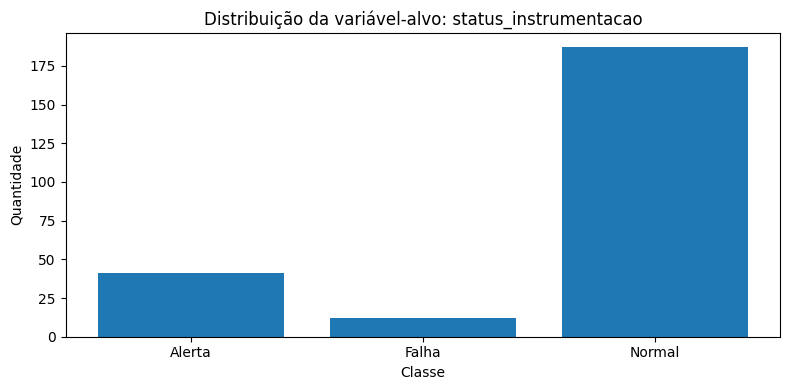

In [4]:
classe_counts = df["status_instrumentacao"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(classe_counts.index, classe_counts.values)
plt.title("Distribuição da variável-alvo: status_instrumentacao")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

## 2. Preparação dos dados

Complete a execução do bloco abaixo e observe a separação entre:
- variáveis preditoras (`X`);
- variável-alvo (`y`).


In [5]:
# Variáveis preditoras (X): tudo o que o modelo usará para aprender
X = df.drop(columns=["status_instrumentacao", "acao_ideal_controle"])

# Variável-alvo (y): aquilo que desejamos prever
y = df["status_instrumentacao"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("\nPrimeiras linhas de X:")
display(X.head())
print("\nPrimeiras linhas de y:")
display(y.head())

Formato de X: (240, 17)
Formato de y: (240,)

Primeiras linhas de X:


,linha_producao,turno,produto_quimico,tipo_valvula,status_sensor,vazao_setpoint_l_min,vazao_real_l_min,erro_vazao_pct,pressao_linha_bar,desvio_pressao_pct,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,tempo_resposta_seg,horas_operacao_bomba
0,Linha_C,Manhã,Base,Borboleta,OK,104.97,115.78,10.30,6.39,10.17,50.19,58.59,2.47,6.37,120.68,2.18,1257
1,Linha_B,Noite,Acido,Esfera,OK,97.21,94.74,-2.54,5.79,-0.17,40.75,26.90,3.79,5.83,143.20,3.59,1892
2,Linha_C,Manhã,Acido,Borboleta,OK,100.91,98.73,-2.16,6.26,7.93,37.14,64.77,4.70,7.67,95.72,3.78,2382
3,Linha_B,Noite,Acido,Borboleta,Ruido,100.07,93.17,-6.90,5.42,-6.55,38.45,73.44,3.34,5.59,88.30,2.64,2543
4,Linha_A,Tarde,Solvente,Esfera,OK,105.38,93.93,-10.87,7.81,34.66,50.91,40.90,6.47,6.54,143.12,4.23,1401



Primeiras linhas de y:


,status_instrumentacao
0,Normal
1,Normal
2,Normal
3,Normal
4,Falha


### Reflexão
- Qual coluna foi escolhida como variável-alvo?

status_instrumentacao.

- Por que ela não deve permanecer dentro de `X`?

Ela não deve permanecer dentro de X (as variáveis preditoras) porque X é usado para treinar o modelo para prever y. Se a variável-alvo estivesse incluída em X, o modelo estaria basicamente aprendendo a prever a si mesmo, o que levaria a um vazamento de dados (data leakage) e a um desempenho superestimado e irreal do modelo.

In [6]:
colunas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:")
print(colunas_numericas)
print("\nColunas categóricas:")
print(colunas_categoricas)

Colunas numéricas:
['vazao_setpoint_l_min', 'vazao_real_l_min', 'erro_vazao_pct', 'pressao_linha_bar', 'desvio_pressao_pct', 'temperatura_produto_c', 'abertura_valvula_pct', 'vibracao_bomba_mm_s', 'ph_produto', 'consumo_energia_kwh', 'tempo_resposta_seg', 'horas_operacao_bomba']

Colunas categóricas:
['linha_producao', 'turno', 'produto_quimico', 'tipo_valvula', 'status_sensor']


## 3. Padronização e preparação da base

Observe como o código trata:
- colunas numéricas;
- colunas categóricas.


In [7]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas)
    ]
)

print("Pré-processador criado com sucesso.")

Pré-processador criado com sucesso.


### Reflexão
- Por que as colunas numéricas são padronizadas?

As colunas numéricas são padronizadas (geralmente usando StandardScaler ou MinMaxScaler) por várias razões:
Escalas Diferentes: Variáveis numéricas podem ter escalas muito diferentes (por exemplo, temperatura_produto_c vs. consumo_energia_kwh). Modelos de Machine Learning, especialmente aqueles baseados em distância (como KNN, K-Means, SVMs) ou gradientes, podem ser sensíveis a essas diferenças, dando mais peso a variáveis com maior magnitude.
Convergência Rápida: A padronização ajuda os algoritmos de otimização (como na regressão logística ou redes neurais) a convergir mais rapidamente, pois todas as variáveis contribuem igualmente para o cálculo do gradiente.
Melhor Desempenho do Modelo: Em muitos casos, a padronização melhora o desempenho e a estabilidade dos modelos, pois evita que uma variável domine as outras apenas por causa de sua escala.

- Por que as colunas categóricas precisam de codificação?

As colunas categóricas (como linha_producao, turno, produto_quimico) precisam de codificação porque a maioria dos algoritmos de Machine Learning opera com dados numéricos. Eles não conseguem entender categorias textuais diretamente. A codificação converte essas categorias em um formato numérico que o modelo pode processar. Uma técnica comum é o OneHotEncoder, que cria novas colunas binárias para cada categoria, evitando que o modelo interprete uma ordem ou relação de magnitude inexistente entre as categorias.


## 4. Divisão da base em treino e validação

Execute o bloco e compare os tamanhos dos conjuntos.


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Formato de X_train:", X_train.shape)
print("Formato de X_val:", X_val.shape)
print("Formato de y_train:", y_train.shape)
print("Formato de y_val:", y_val.shape)

Formato de X_train: (180, 17)
Formato de X_val: (60, 17)
Formato de y_train: (180,)
Formato de y_val: (60,)


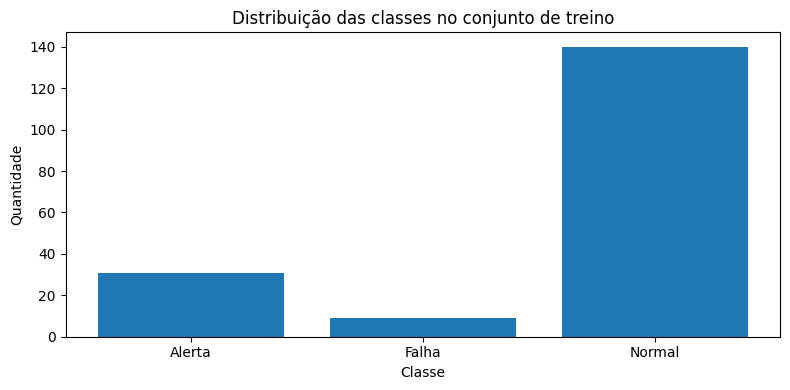

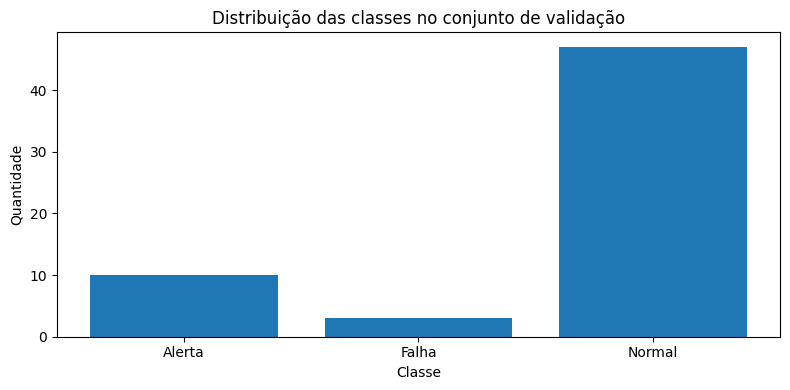

In [9]:
train_counts = y_train.value_counts().sort_index()
val_counts = y_val.value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(train_counts.index, train_counts.values)
plt.title("Distribuição das classes no conjunto de treino")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(val_counts.index, val_counts.values)
plt.title("Distribuição das classes no conjunto de validação")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

### Reflexão
- Qual é a função do conjunto de treino?

 O conjunto de treino é usado para ensinar o modelo de Machine Learning. Durante o treinamento, o modelo ajusta seus parâmetros internos (pesos e vieses para uma rede neural, ou divisões para uma árvore de decisão) com base nos dados de treino para aprender os padrões e relacionamentos entre as variáveis preditoras (X_train) e a variável-alvo (y_train).

- Qual é a função do conjunto de validação?

O conjunto de validação (ou teste) é usado para avaliar o desempenho do modelo depois que ele foi treinado. Ele consiste em dados que o modelo nunca viu durante o treinamento. A função principal é:

Avaliar Generalização: Verificar se o modelo consegue prever corretamente em dados novos e não vistos, indicando sua capacidade de generalização.
Identificar Overfitting/Underfitting: Ajuda a identificar se o modelo está superajustado (memorizou os dados de treino e não generaliza bem) ou subajustado (não aprendeu os padrões adequadamente).
Seleção de Modelos e Hiperparâmetros: Utilizado para comparar diferentes modelos ou ajustar hiperparâmetros (por exemplo, max_depth de uma árvore de decisão) e escolher a melhor configuração.

- O que significa preservar a proporção das classes?

reservar a proporção das classes significa que, ao dividir o conjunto de dados em treino e validação, a porcentagem de cada classe na variável-alvo (y) é mantida a mesma (ou muito próxima) nos subconjuntos de treino e validação. Isso é especialmente importante em datasets com classes desbalanceadas (onde uma classe tem muito mais exemplos do que outras). Se a proporção não for mantida, o conjunto de treino ou validação pode ter uma representação enviesada das classes, o que pode levar o modelo a aprender padrões incorretos ou ter um desempenho de avaliação irreal.

## 5. Criação do modelo supervisionado

In [10]:
modelo_supervisionado = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", DecisionTreeClassifier(max_depth=4, random_state=42))
])

print(modelo_supervisionado)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['vazao_setpoint_l_min',
                                                   'vazao_real_l_min',
                                                   'erro_vazao_pct',
                                                   'pressao_linha_bar',
                                                   'desvio_pressao_pct',
                                                   'temperatura_produto_c',
                                                   'abertura_valvula_pct',
                                                  

## 6. Treino, validação e métricas

In [11]:
modelo_supervisionado.fit(X_train, y_train)
pred_supervisionado = modelo_supervisionado.predict(X_val)

acc = accuracy_score(y_val, pred_supervisionado)

print("Acurácia na validação:", round(acc, 4))
print("\nRelatório de classificação:")
print(classification_report(y_val, pred_supervisionado))

Acurácia na validação: 0.7667

Relatório de classificação:
              precision    recall  f1-score   support

      Alerta       0.17      0.10      0.12        10
       Falha       0.00      0.00      0.00         3
      Normal       0.85      0.96      0.90        47

    accuracy                           0.77        60
   macro avg       0.34      0.35      0.34        60
weighted avg       0.69      0.77      0.73        60



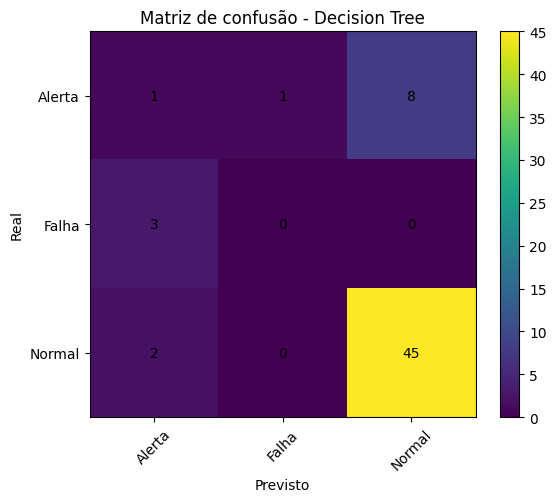

In [12]:
labels = sorted(y.unique())
cm = confusion_matrix(y_val, pred_supervisionado, labels=labels)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Matriz de confusão - Decision Tree")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

### Reflexão
- Qual foi a acurácia obtida?

A acurácia obtida foi de aproximadamente 0.7667 (ou 76.67%).

- Em quais classes o modelo parece ter acertado mais?

O modelo parece ter acertado mais na classe 'Normal'. Conforme o relatório de classificação e a matriz de confusão, ele conseguiu prever corretamente 45 das 47 instâncias 'Normal' (recall de 0.96) e teve uma precisão de 0.85 para essa classe.

- Onde houve confusão?

Houve bastante confusão, especialmente nas classes 'Alerta' e 'Falha':
Classe 'Alerta': Das 10 instâncias reais de 'Alerta', apenas 1 foi classificada corretamente como 'Alerta'. 1 foi classificada como 'Falha' e 8 foram classificadas incorretamente como 'Normal'.
Classe 'Falha': Todas as 3 instâncias reais de 'Falha' foram classificadas incorretamente como 'Alerta'. Nenhuma foi classificada corretamente como 'Falha'.
Classe 'Normal': Embora tenha tido um bom desempenho geral, 2 das 47 instâncias 'Normal' foram incorretamente classificadas como 'Alerta'.


## 7. Demonstração não supervisionada

In [13]:
X_cluster = df.drop(columns=["status_instrumentacao", "acao_ideal_controle"]).copy()

colunas_numericas_cluster = X_cluster.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas_cluster = X_cluster.select_dtypes(include=["object"]).columns.tolist()

preprocessador_cluster = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas_cluster),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas_cluster)
    ]
)

X_cluster_transformado = preprocessador_cluster.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_transformado)

sil = silhouette_score(X_cluster_transformado, clusters)

print("Silhouette Score:", round(sil, 4))
print(pd.Series(clusters).value_counts().sort_index())

Silhouette Score: 0.0761
0    107
1     71
2     62
Name: count, dtype: int64


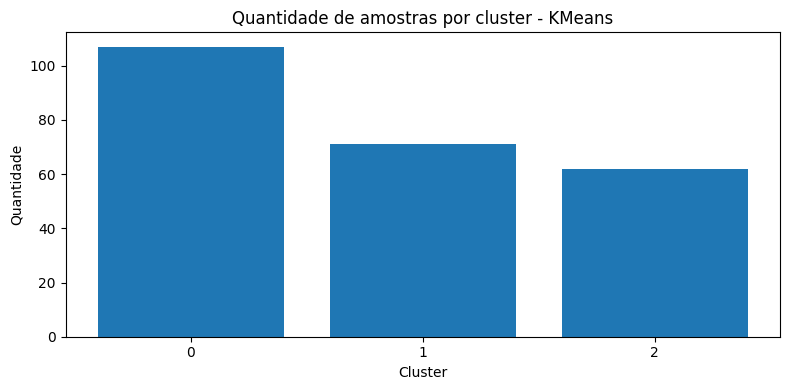

In [14]:
cluster_counts = pd.Series(clusters).value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Quantidade de amostras por cluster - KMeans")
plt.xlabel("Cluster")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

### Reflexão
- O que o KMeans está tentando encontrar?

O algoritmo K-Means está tentando encontrar agrupamentos (clusters) intrínsecos nos dados. Ele busca particionar os dados em K grupos, onde K é um número pré-definido. O objetivo é que os pontos de dados dentro de um mesmo cluster sejam o mais semelhantes possível entre si, e o mais diferentes possível dos pontos de dados em outros clusters. Ele faz isso minimizando a soma das distâncias quadradas entre cada ponto e o centro (centróide) do cluster ao qual ele pertence.

- Por que ele não precisa da variável-alvo?

 K-Means não precisa da variável-alvo porque é um algoritmo de aprendizado não supervisionado. No aprendizado não supervisionado, o objetivo não é prever um rótulo ou valor específico (como a status_instrumentacao no aprendizado supervisionado), mas sim descobrir padrões, estruturas ou relações ocultas nos dados sem nenhuma informação prévia sobre os rótulos corretos. Ele aprende a agrupar os dados apenas com base nas características (X) de cada amostra.


## 8. Demonstração semi-supervisionada

In [15]:
X_semi = df.drop(columns=["status_instrumentacao", "acao_ideal_controle"])
y_semi = df["status_instrumentacao"].copy()

colunas_numericas_semi = X_semi.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas_semi = X_semi.select_dtypes(include=["object"]).columns.tolist()

preprocessador_semi = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas_semi),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas_semi)
    ]
)

X_semi_transformado = preprocessador_semi.fit_transform(X_semi)

label_encoder = LabelEncoder()
y_codificado = label_encoder.fit_transform(y_semi)

rng = np.random.default_rng(42)
y_parcial = y_codificado.copy()
indices_sem_rotulo = rng.choice(len(y_parcial), size=int(len(y_parcial) * 0.6), replace=False)
y_parcial[indices_sem_rotulo] = -1

modelo_semi = LabelSpreading(kernel="knn", n_neighbors=7)
modelo_semi.fit(X_semi_transformado, y_parcial)

rotulos_previstos = modelo_semi.transduction_

mascara_rotulada = y_parcial != -1
mascara_nao_rotulada = y_parcial == -1

acc_rot = accuracy_score(y_codificado[mascara_rotulada], rotulos_previstos[mascara_rotulada])
acc_nao_rot = accuracy_score(y_codificado[mascara_nao_rotulada], rotulos_previstos[mascara_nao_rotulada])

print("Acurácia nas amostras rotuladas:", round(acc_rot, 4))
print("Acurácia nas amostras sem rótulo para o algoritmo:", round(acc_nao_rot, 4))

Acurácia nas amostras rotuladas: 1.0
Acurácia nas amostras sem rótulo para o algoritmo: 0.7847


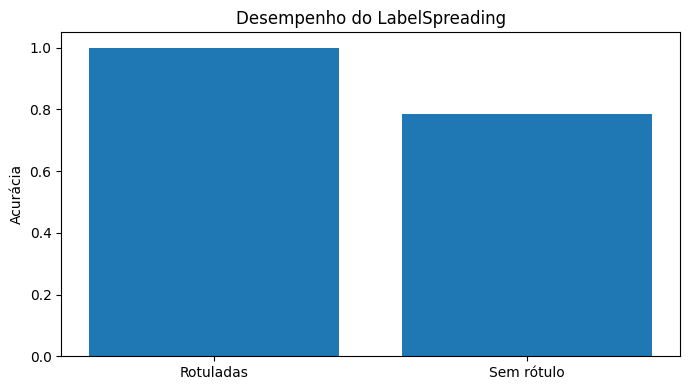

In [16]:
plt.figure(figsize=(7,4))
plt.bar(["Rotuladas", "Sem rótulo"], [acc_rot, acc_nao_rot])
plt.title("Desempenho do LabelSpreading")
plt.ylabel("Acurácia")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Reflexão
- O que muda quando parte dos rótulos é escondida?

Quando parte dos rótulos é escondida (ou propositalmente não usada para o treinamento), a abordagem se move do aprendizado supervisionado (onde todos os dados têm rótulos) para o aprendizado semi-supervisionado. O algoritmo de aprendizado semi-supervisionado (LabelSpreading neste caso) tenta inferir os rótulos dos dados não rotulados usando tanto os dados rotulados disponíveis quanto as relações de similaridade entre todos os dados (rotulados e não rotulados) no conjunto de dados.

- Qual é a vantagem desse tipo de abordagem?

A principal vantagem da abordagem semi-supervisionada é que ela permite construir modelos mais robustos e precisos em cenários onde a obtenção de dados rotulados é cara, demorada ou difícil. Em muitas situações do mundo real, temos uma grande quantidade de dados não rotulados, mas apenas uma pequena fração com rótulos. O aprendizado semi-supervisionado aproveita essa abundância de dados não rotulados, juntamente com a pequena quantidade de dados rotulados, para melhorar o desempenho do modelo, que seria subótimo se usasse apenas os dados rotulados.

## 9. Demonstração da lógica do reforço

In [17]:
acoes_possiveis = ["Aumentar_Abertura", "Manter_Ajuste", "Reduzir_Abertura"]

df_rl = df[["erro_vazao_pct", "acao_ideal_controle"]].copy()

rng = np.random.default_rng(42)
acoes_aleatorias = rng.choice(acoes_possiveis, size=len(df_rl))
df_rl["acao_agente_aleatorio"] = acoes_aleatorias
df_rl["recompensa_aleatoria"] = np.where(
    df_rl["acao_agente_aleatorio"] == df_rl["acao_ideal_controle"], 1, -1
)

def politica_heuristica(erro):
    if erro < -3:
        return "Aumentar_Abertura"
    elif erro > 3:
        return "Reduzir_Abertura"
    else:
        return "Manter_Ajuste"

df_rl["acao_heuristica"] = df_rl["erro_vazao_pct"].apply(politica_heuristica)
df_rl["recompensa_heuristica"] = np.where(
    df_rl["acao_heuristica"] == df_rl["acao_ideal_controle"], 1, -1
)

recompensa_total_agente = df_rl["recompensa_aleatoria"].sum()
recompensa_total_heuristica = df_rl["recompensa_heuristica"].sum()

print("Recompensa total do agente aleatório:", recompensa_total_agente)
print("Recompensa total da heurística:", recompensa_total_heuristica)

Recompensa total do agente aleatório: -64
Recompensa total da heurística: 240


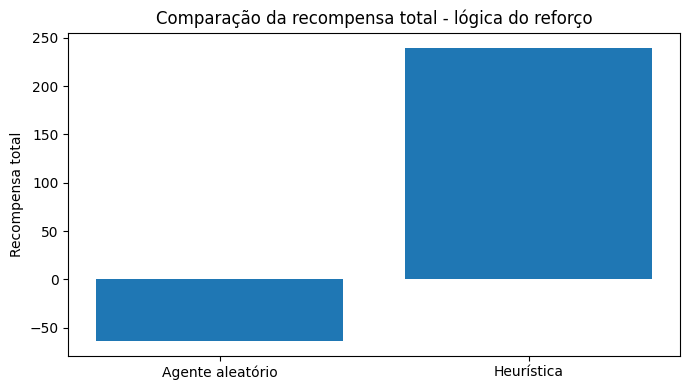

In [18]:
plt.figure(figsize=(7,4))
plt.bar(["Agente aleatório", "Heurística"], [recompensa_total_agente, recompensa_total_heuristica])
plt.title("Comparação da recompensa total - lógica do reforço")
plt.ylabel("Recompensa total")
plt.tight_layout()
plt.show()

### Reflexão
- O que representa o estado?

o contexto de aprendizado por reforço, o estado representa a situação atual do ambiente observada pelo agente. É a informação disponível que o agente usa para decidir qual ação tomar. No exemplo que temos, o estado é representado pelo erro_vazao_pct (porcentagem de erro na vazão), que informa ao agente o quão grande e em que direção está o desvio da vazão.

- O que representa a ação?

A ação é a decisão que o agente toma em um determinado estado para influenciar o ambiente. No nosso caso, as ações possíveis são Aumentar_Abertura, Manter_Ajuste ou Reduzir_Abertura, que representam os comandos de controle que o agente pode enviar para a válvula para corrigir o erro de vazão.

- O que representa a recompensa?

A recompensa é um sinal numérico que o ambiente envia ao agente após cada ação, indicando a qualidade dessa ação. É o feedback que o agente utiliza para aprender qual é a melhor política de ações. No exemplo, uma recompensa de +1 é dada se a acao_agente_aleatorio ou acao_heuristica for igual à acao_ideal_controle, e -1 caso contrário. O objetivo do agente é maximizar a recompensa total ao longo do tempo.
- Por que essa lógica é diferente dos outros tipos de aprendizado?
Essa lógica é diferente dos outros tipos de aprendizado (supervisionado e não supervisionado) principalmente por causa de:
Feedback Atrasado/Indireto: No aprendizado supervisionado, o modelo recebe o 'rótulo correto' para cada entrada imediatamente. No reforço, a recompensa pode não ser imediata ou diretamente associada a uma única ação, mas sim a uma sequência de ações. O agente precisa aprender a associar ações de longo prazo a recompensas futuras.
Interação com o Ambiente: O aprendizado por reforço envolve um agente que interage ativamente com um ambiente dinâmico. O agente toma ações, o ambiente muda de estado e fornece recompensas, e o agente aprende com essa experiência de tentativa e erro. Diferentemente do aprendizado supervisionado e não supervisionado, onde o foco é em dados estáticos.
Objetivo de Otimização: O objetivo principal não é apenas classificar ou agrupar dados, mas sim aprender uma política (um mapeamento de estados para ações) que maximize a recompensa acumulada ao longo do tempo. Isso geralmente envolve lidar com o dilema exploração-explotação, onde o agente precisa explorar novas ações para encontrar as melhores e, ao mesmo tempo, explorar as ações que já sabe que dão boas recompensas.

## 10. Comparação visual final

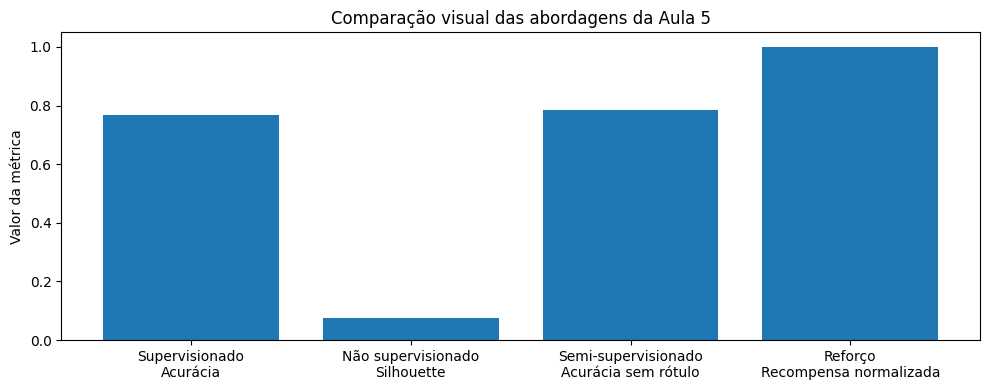

In [19]:
metricas = {
    "Supervisionado\nAcurácia": acc,
    "Não supervisionado\nSilhouette": sil,
    "Semi-supervisionado\nAcurácia sem rótulo": acc_nao_rot,
    "Reforço\nRecompensa normalizada": recompensa_total_heuristica / len(df)
}

plt.figure(figsize=(10,4))
plt.bar(list(metricas.keys()), list(metricas.values()))
plt.title("Comparação visual das abordagens da Aula 5")
plt.ylabel("Valor da métrica")
plt.tight_layout()
plt.show()

## 11. Registro final do aluno

Preencha:
- Qual tipo de aprendizado é mais adequado ao projeto atual?

Para o projeto atual, que busca prever o status_instrumentacao (uma tarefa de classificação), o aprendizado supervisionado é o tipo mais adequado. Ele é ideal quando se tem dados históricos com rótulos (status_instrumentacao conhecido) e o objetivo é treinar um modelo para prever esses rótulos em novos dados.

- Qual abordagem poderia complementar a análise?

A abordagem semi-supervisionada (LabelSpreading) poderia ser um excelente complemento para a análise. Em cenários industriais, obter dados rotulados (por exemplo, classificar cada evento como 'Normal', 'Alerta' ou 'Falha') pode ser um processo caro e demorado. O aprendizado semi-supervisionado aproveita tanto os dados rotulados disponíveis (mesmo que poucos) quanto a grande quantidade de dados não rotulados para melhorar o desempenho do modelo, inferindo os rótulos dos dados não identificados. Isso pode levar a um modelo mais robusto sem a necessidade de rotular todo o conjunto de dados. Além disso, o aprendizado não supervisionado (KMeans) poderia complementar a análise ao ajudar a identificar padrões ou agrupamentos naturais nos dados que talvez não sejam óbvios. Esses clusters podem revelar diferentes regimes de operação ou tipos de falhas que podem ser incorporados como novas características no modelo supervisionado.

- O que você entendeu sobre preparação dos dados, treino, validação e métricas?

Preparação dos Dados: É a etapa crucial de transformar os dados brutos em um formato que os modelos de Machine Learning possam entender e utilizar. Isso envolve identificar as variáveis preditoras (X) e a variável-alvo (y), tratar valores ausentes (com SimpleImputer), padronizar as colunas numéricas (StandardScaler) para que todas tenham escalas semelhantes e codificar as colunas categóricas (OneHotEncoder) para convertê-las em um formato numérico. Essa etapa garante que os dados estejam limpos e prontos para o aprendizado.
Treino: É o processo onde o modelo de Machine Learning é 'alimentado' com o conjunto de dados de treino (X_train, y_train). Durante o treino, o modelo ajusta seus parâmetros internos para aprender os padrões e relações entre as variáveis de entrada e a variável-alvo, buscando minimizar erros e otimizar seu desempenho.
Validação: Após o treino, o modelo é avaliado usando um conjunto de dados separado e não visto (X_val, y_val). A validação serve para verificar a capacidade de generalização do modelo, ou seja, quão bem ele se comporta com novos dados. Ajuda a identificar se o modelo está superajustado (memorizou o treino, mas não generaliza bem) ou subajustado (não aprendeu os padrões adequadamente).
Métricas: São ferramentas quantitativas usadas para medir e interpretar o desempenho de um modelo. No aprendizado supervisionado, métricas como acurácia, precision, recall, f1-score e matriz de confusão fornecem uma visão detalhada de quão bem o modelo está classificando as instâncias em cada classe. No aprendizado não supervisionado, o Silhouette Score ajuda a avaliar a qualidade dos clusters formados. As métricas são essenciais para entender os pontos fortes e fracos do modelo e para comparar diferentes abordagens.